# Assignement 2

### <span style="color:chocolate"> Submission requirements </span>

Your homework will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [204]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### Define functions

In [205]:
def create_1d_data(num_examples, w, b, bound):
  """Create X, Y data with a linear relationship with added noise.

  Args:
    num_examples: number of examples to generate
    w: desired slope
    b: desired intercept
    bound: lower and upper boundary of the data interval

  Returns:
    X and Y with shape (num_examples)
  """
  np.random.seed(4)  # consistent random number generation
  X = np.arange(num_examples)
  deltas = np.random.uniform(low=-bound, high=bound, size=X.shape) # added noise
  Y = b + deltas + w * X

  return X, Y

---
### Step 1: Data ingestion

Let's start by creating some artificial data using the <span style="color:chocolate">create_1d_data()</span> function defined at the top of the notebook.

In [206]:
# Define parameters
num_examples = 70
w = 2
b = 1
bound = 1

# Create data
X, Y = create_1d_data(num_examples, w, b, bound)

# Print shapes
print('Printing shape of X:', X.shape)
print('Printing first 10 elements in X:', X[:10])
print('\nPrinting shape of Y:', Y.shape)
print('Printing first 10 elements in Y:', Y[:10])

Printing shape of X: (70,)
Printing first 10 elements in X: [0 1 2 3 4 5 6 7 8 9]

Printing shape of Y: (70,)
Printing first 10 elements in Y: [ 1.93405968  3.0944645   5.94536872  7.42963199  9.39545765 10.43217899
 13.95254891 14.01246051 16.50596472 18.86958306]


---
### Step 2: Data Preprocessing

Our objectives here involve adding one more feature to X and creating data partitions.

### <span style="color:chocolate">Exercise 1:</span> Adding features (10 points)

1. Add a column of $1s$ to $X$ (this will serve as an intercept or "bias" in our modeling task later on). Note: do not create a new array, just concatenate with the current values;
2. Print the shape of the array.

In [207]:

X = np.concatenate((np.ones((70,1)),X.reshape(70,1)), axis=1)
print(f"Exercise 1: {X.shape}")

Exercise 1: (70, 2)


### <span style="color:chocolate">Exercise 2:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Split the (X,Y) data into training and test paritions by setting test_size=0.2 and random_state=1234. All the other arguments of the method are set to default values. Name the resulting arrays X_train, X_test, Y_train, Y_test;
2. Print the shape of each array.

In [224]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=1234)
print("Exercise 2 shape of arrays:")
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


Exercise 2 shape of arrays:
(56, 2)
(14, 2)
(56,)
(14,)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 3:</span> Plots (10 points)

Create a side-by-side histogram for the values in Y_train and X_train. Make sure to include axes name and titles for each subplot.

/var/folders/mh/jccrgn2s0ddfhbczzw62dyw00000gn/T/ipykernel_49330/840270422.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


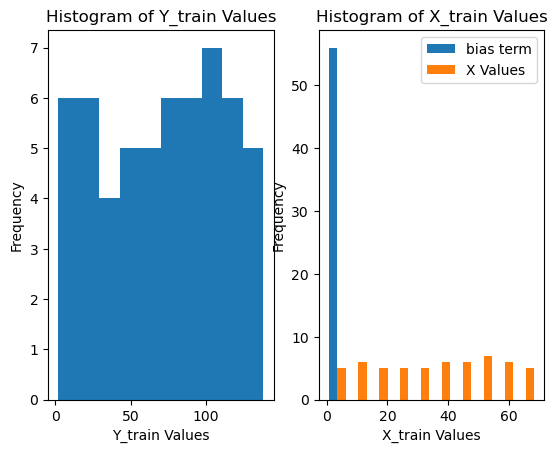

In [209]:
fig, ax = plt.subplots(1,2)
ax[0].hist(Y_train)
ax[0].set_title("Histogram of Y_train Values")
ax[0].set_xlabel("Y_train Values")
ax[0].set_ylabel("Frequency")
ax[1].hist(X_train, label = ("bias term", "X Values"))
ax[1].set_title("Histogram of X_train Values")
ax[1].set_xlabel("X_train Values")
ax[1].set_ylabel("Frequency")
ax[1].legend()
fig.show()



---
### Step 4: Modeling

Let's start by considering the two models proposed in Assignment 1:
1. $M_1(x) = 5+x$ 
2. $M_2(x) = 1+2x$

### <span style="color:chocolate">Exercise 4:</span> Practice with Parameters (10 points)

Perform the following computations:

1. Use matrix multiplication (np.dot) to create $M_1$ and $M_2$ (as previously defined) to produce vectors of predictions using the X_train data. Call these predictions M1_hat_train, M2_hat_train. Hint: the "learned" parameters are alredy provided to you;
3. Print the shapes of the predictions to verify that they match the shape of Y_train.

In [210]:
#M1_hat_train = np.dot(X_train, (np.ones((2,))*5))
#M2_hat_train = np.dot((2 * X_train) , (np.ones((2,))))

W1 = np.array([5, 1])
W2 = np.array([1, 2])
M1_hat_train = np.dot(X_train, W1.T)
M2_hat_train = np.dot(X_train, W2.T)

print("Shape of Exercise 4 solutions: M1_hat_train and M2_hat_train:")
print(M1_hat_train.shape)
print(M2_hat_train.shape)



Shape of Exercise 4 solutions: M1_hat_train and M2_hat_train:
(56,)
(56,)


### <span style="color:chocolate">Exercise 5:</span> Learn parameters with Gradient Descent (20 points)

1. Fill in the <span style="color:green">NotImplemented</span> parts of the <span style="color:chocolate">gradient_descent()</span> function below. Hint: refer to ``02 Linear Regression_helper.ipynb file``;

2. Run this function with our artificial (X_train, Y_train) data . Set learning_rate = .0002 and num_epochs = 5. Print out the weights and loss after each epoch. 

3. Generate a plot with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

In [211]:
num_epochs = 5
for i in range(num_epochs):
    print(i)



0
1
2
3
4


In [212]:
def gradient_descent(inputs, outputs, learning_rate, num_epochs):
  """Apply the gradient descent algorithm to learn learn linear regression.

  Args:
    inputs: A 2-D array where each column is an input feature and each
            row is a training example.
    outputs: A 1-D array containing the real-valued
             label corresponding to the input data in the same row.
    learning_rate: The learning rate to use for updates.
    num_epochs: The number of passes through the full training data.

  Returns:
    weights: A 2-D array with the learned weights after each training epoch.
    losses: A 1-D array with the loss after each epoch.
  """
  # m = number of examples, n = number of features
  m, n = inputs.shape
  
  # We'll use a vector of size n to store the learned weights and initialize
  # all weights to 1. 
  W = np.ones(n)
  
  # Keep track of the training loss and weights after each step.
  losses = []
  weights = []
  
  for epoch in range(num_epochs):
    # Append the old weights to the weights list to keep track of them.
    weights.append(W)

    # Evaluate the current predictions for the training examples given
    # the current estimate of W. 
    predictions = np.dot(inputs, W.T)
    
    # Find the difference between the predictions and the actual target
    # values.
    diff = predictions - outputs
    
    # In standard linear regression, we want to minimize the sum of squared
    # differences. Compute the mean squared error loss. Don't bother with the
    # 1/2 scaling factor here.
    loss = np.mean((diff ** 2))

    # Append the loss to the losses list to keep a track of it.
    losses.append(loss)
    
    # Compute the gradient with respect to the loss.
    # [Formula (4) in the Gradient Descent Implementation]
    gradient = np.dot(diff, inputs) / m

    # Update weights, scaling the gradient by the learning rate.
    W = W - learning_rate * gradient

  # Append the final weights after the loop
  weights.append(W)
      
  return np.array(weights), np.array(losses)

In [213]:
gradient_descent(X_train, Y_train, 0.0002, 5)

(array([[1.        , 1.        ],
        [1.00709394, 1.33262886],
        [1.01183193, 1.55469157],
        [1.01499708, 1.7029404 ],
        [1.01711221, 1.80191116],
        [1.01852634, 1.8679839 ]]),
 array([1665.36666086,  742.41486626,  331.06572624,  147.73208293,
          66.02235863]))

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning plays an important role in optimizing ML models. One systematically adjusts hyperparameters to find the right balance between model complexity and generalization, ultimately leading to better predictive performance and model effectiveness.

Note that hyperparameter tuning is typically performed on **a separate validation dataset**. However, for the purposes of this assignment and based on the ML knowledge you've acquired thus far, we will perform hyperparameter tuning directly on the training data.

### <span style="color:chocolate">Exercise 6:</span> Tuning hyperparameters (10 points)

Answer the following questions:
    
1. Do you think it would be beneficial to extend the model training in Exercise 5 by increasing the learning rate to 0.02? Justify your answer;

2. Restoring to the previous learning_rate = .0002, would you  consider extending the model training in Exercise 5 by increasing the number of epochs to 10? Justify your answer.

Note: to support your answers, we recommend the following actions:
- create side-by-side subplots to show the loss at each epoch (make sure to include axes name and title), and
- print the loss at the last epoch under the following scenarios:
    - learning_rate=.0002, num_epochs=5;
    - learning_rate=.02, num_epochs=5;
    - learning_rate=.0002, num_epochs=10.

/var/folders/mh/jccrgn2s0ddfhbczzw62dyw00000gn/T/ipykernel_49330/1371448387.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


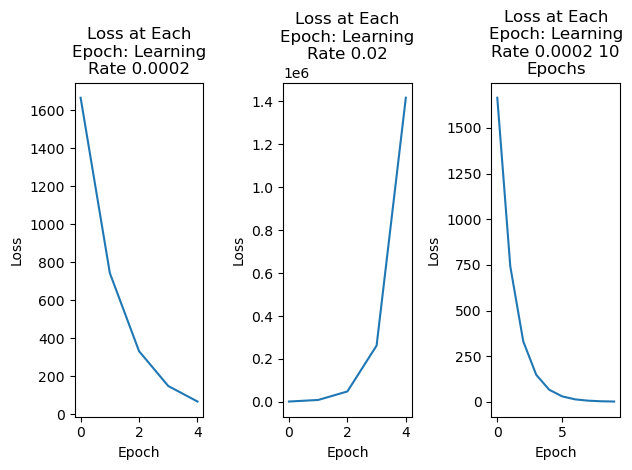

In [214]:
from textwrap import wrap

fig, ax = plt.subplots(1,3)
ax[0].set_title("\n".join(wrap("Loss at Each Epoch: Learning Rate 0.0002",15)))
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
weights_v1, losses_v1 = gradient_descent(
    X_train, Y_train,
    learning_rate=.0002, num_epochs=5
)
ax[0].plot(losses_v1)
ax[1].set_title("\n".join(wrap("Loss at Each Epoch: Learning Rate 0.02",15)))
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
weights_v2, losses_v2 = gradient_descent(
    X_train, Y_train,
    learning_rate=.002, num_epochs=5
)
ax[1].plot(losses_v2)
ax[2].set_title("\n".join(wrap("Loss at Each Epoch: Learning Rate 0.0002 10 Epochs",15)))
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
weights_v3, losses_v3 = gradient_descent(
    X_train, Y_train,
    learning_rate=.0002, num_epochs=10
)
ax[2].plot(losses_v3)
fig.tight_layout()
fig.show()

In [215]:
print(f" Last loss learning rate 0.0002 5 epochs: {np.round(losses_v1[-1],2)}")
print(f" Last loss learning rate 0.02 5 epochs: {np.round(losses_v2[-1],2)}")
print(f" Last loss learning rate 0.0002 10 epochs: {np.round(losses_v3[-1],2)}")

print("1. Looking at the plots above, it would not be a good idea to increase the learning rate to " \
"0.02. It makes the loss explode when the learning rate is too big.")

print("2. I would consider increasing the epochs after looking at the graphs above. It seems \n" \
"loss is lowest when error is 0.0002 and we do 10 epochs.")

 Last loss learning rate 0.0002 5 epochs: 66.02
 Last loss learning rate 0.02 5 epochs: 1416859.41
 Last loss learning rate 0.0002 10 epochs: 1.48
1. Looking at the plots above, it would not be a good idea to increase the learning rate to 0.02. It makes the loss explode when the learning rate is too big.
2. I would consider increasing the epochs after looking at the graphs above. It seems 
loss is lowest when error is 0.0002 and we do 10 epochs.


### <span style="color:chocolate">Exercise 7:</span> Choosing the best model (10 points)

Write down the learned model that you consider most optimal given your answers to the hyperparameter tuning exercise. Call this model $M_3(x)$.

In [221]:
M3_X = np.dot(X_train, (weights_v3)[-1].T)
print(f"M3 has the lowest loss according to my findings in exercise 6, so I will use W0 and W1 from \n"\
      "the iteration of my gradient descent algorithm with learning rate 0.0002 and 10 epochs \n"\
        "to be my parameters for model 3.")


M3 has the lowest loss according to my findings in exercise 6, so I will use W0 and W1 from 
the iteration of my gradient descent algorithm with learning rate 0.0002 and 10 epochs 
to be my parameters for model 3.


---
### Step 6: Evaluation and Generalization

To evaluate our models, we assess their performance based on how closely they fit the available data. In other words, we compare the true value $y$ with the predicted value $\hat{y}$ for each $x$.

### <span style="color:chocolate">Exercise 8:</span> Computing MSE (10 points)

Assess the performance of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) by computing the MSE metric on the training dataset. Hint: you can use the <span style="color:chocolate">mean_squared_error()</span> method available in sklearn.metrics.

In [222]:
M1_mse = mean_squared_error(Y_train, M1_hat_train)
print(f"M1 mse: {M1_mse}")

M2_mse = mean_squared_error(Y_train, M2_hat_train)
print(f"M2 mse: {M2_mse}")

M3_mse = mean_squared_error(Y_train, M3_X)
print(f"M3 mse: {M3_mse}")

M1 mse: 1397.608983658733
M2 mse: 0.3280557752885262
M3 mse: 0.8393687909121669


### <span style="color:chocolate">Exercise 9:</span> Generalization (10 points)

Which of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) demonstrates better generalization ability? Hint: compare training vs. test MSE.

In [223]:
M1_hat_test = np.dot(X_test, (np.ones((2,))*5))
M1_test_mse = mean_squared_error(Y_test, M1_hat_test)
print(f"M1 train mse: {M1_mse}, M1 test mse: {M1_test_mse}")

M2_hat_test = np.dot((2 * X_test) , (np.ones((2,))))
M2_test_mse = mean_squared_error(Y_test, M2_hat_test)
print(f"M2 train mse: {M2_mse}, M2 test mse: {M2_test_mse}")

M3_test = np.dot(X_test, (weights_v3)[-1].T)
M3_test_mse = mean_squared_error(Y_test, M3_test)
print(f"M3 train mse: {M3_mse}, M3 test mse: {M3_test_mse}")

print("Based on the mse comparisons of train vs test, model 3 has the MSE that is most consistent \n"\
      "across test mse and train MSE, so model 3 has the best generalizability. The fact that M2 has \n"\
            "the lowest test set MSE is misleading.")

M1 train mse: 1397.608983658733, M1 test mse: 12896.209324035064
M2 train mse: 0.3280557752885262, M2 test mse: 1.4062566168172699
M3 train mse: 0.8393687909121669, M3 test mse: 0.6026016556635998
Based on the mse comparisons of train vs test, model 3 has the MSE that is most consistent 
across test mse and train MSE, so model 3 has the best generalizability. The fact that M2 has 
the lowest test set MSE is misleading.


----
### <span style="color:chocolate">Exercise 10:</span> Additional practice (not graded)

1. How does stochastic gradient descent (SGD) differ from the gradient descent (GD) approach implemented in Exercise 5?
2. Determine the optimal weights for model $M_3(x)$ using SGD. Does SGD converge more rapidly? Explain the reasons for your answer.

In [219]:
# YOUR ANSWER HERE

In [220]:
# YOUR CODE HERE